In [ ]:
!su wedo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
#Check this site for the latest download link https://www.apache.org/dyn/closer.lua/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!wget -q https://dlcdn.apache.org/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!tar xf spark-3.2.1-bin-hadoop3.2.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j

import os
import sys
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
# os.environ["SPARK_HOME"] = "/content/spark-3.2.1-bin-hadoop3.2"


import findspark
findspark.init()
findspark.find()

import pyspark


Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
45 packages can be upgraded. Run 'apt list --upgradable' to see them.
tar: spark-3.2.1-bin-hadoop3.2.tgz: Cannot open: No such file or directory
tar: Error is not recov

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
spark = SparkSession.builder.getOrCreate()

mushroomDataset = spark.read.option("inferSchema", "true").csv("/content/mushroom_cleaned 2.csv", header = True)

mushroomDataset = mushroomDataset.select("cap-diameter", "cap-shape", "gill-attachment", "gill-color","stem-height", "stem-width", "stem-color", "season", "class")

mushroomDataset.show(10)

+------------+---------+---------------+----------+------------------+----------+----------+------------------+-----+
|cap-diameter|cap-shape|gill-attachment|gill-color|       stem-height|stem-width|stem-color|            season|class|
+------------+---------+---------------+----------+------------------+----------+----------+------------------+-----+
|        1372|        2|              2|        10|3.8074667544799388|      1545|        11|1.8042727086281731|    1|
|        1461|        2|              2|        10|3.8074667544799388|      1557|        11|1.8042727086281731|    1|
|        1371|        2|              2|        10|3.6124962945838073|      1566|        11|1.8042727086281731|    1|
|        1261|        6|              2|        10|3.7875718095925786|      1566|        11|1.8042727086281731|    1|
|        1305|        6|              2|        10| 3.711971019020609|      1464|        11|0.9431945538974952|    1|
|        1337|        6|              2|        10|3.775

In [ ]:
mushroomDataset = mushroomDataset.na.drop()

In [ ]:
mushroomDataset = mushroomDataset.dropDuplicates()

In [ ]:
cols = mushroomDataset.columns
cols.remove("class")

mushroomDataset = VectorAssembler(inputCols = cols, outputCol = "Features").transform(mushroomDataset)
random_seed = 42
(trainingData, testingData) = mushroomDataset.randomSplit([0.7 , 0.3], seed = random_seed)

trainingData.show(5)

testingData.show(5)



+------------+---------+---------------+----------+------------------+----------+----------+------------------+-----+--------------------+
|cap-diameter|cap-shape|gill-attachment|gill-color|       stem-height|stem-width|stem-color|            season|class|            Features|
+------------+---------+---------------+----------+------------------+----------+----------+------------------+-----+--------------------+
|           0|        6|              0|        11| 1.019046875193687|        21|        12|0.9431945538974952|    1|[0.0,6.0,0.0,11.0...|
|           1|        2|              1|         6|0.8956982168920526|        42|         7|0.9431945538974952|    1|[1.0,2.0,1.0,6.0,...|
|           2|        0|              0|         3| 1.452756673738143|       174|         6|0.9431945538974952|    1|[2.0,0.0,0.0,3.0,...|
|           2|        2|              1|         6|1.0588367649684076|        31|         7|0.9431945538974952|    1|[2.0,2.0,1.0,6.0,...|
|           2|        6|   

In [ ]:
scaler = StandardScaler(inputCol = "Features", outputCol = "scaledFeatures")
scaler_model = scaler.fit(trainingData)
trainingData = scaler_model.transform(trainingData)
testingData = scaler_model.transform(testingData)

gbt = GBTClassifier(labelCol="class", featuresCol="scaledFeatures", maxIter=100)


model = gbt.fit(trainingData)
predictions = model.transform(testingData)

predictions.show()

evaluator = MulticlassClassificationEvaluator(labelCol = "class", predictionCol = "prediction", metricName="accuracy")

accuracy = evaluator.evaluate(predictions)

print("Accuracy: {:.2f}%".format(accuracy * 100))

+------------+---------+---------------+----------+------------------+----------+----------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+----------+
|cap-diameter|cap-shape|gill-attachment|gill-color|       stem-height|stem-width|stem-color|              season|class|            Features|      scaledFeatures|       rawPrediction|         probability|prediction|
+------------+---------+---------------+----------+------------------+----------+----------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+----------+
|           1|        6|              0|        11|1.1981013791799302|         1|        11|  0.8884502877862838|    1|[1.0,6.0,0.0,11.0...|[0.00278240447364...|[-1.8747849517072...|[0.02298702730599...|       1.0|
|           3|        6|              0|        11|1.0986266547431285|        22|        11|  0.8884502877862838|    1|[3.0,6.0,0.0,11.0...|

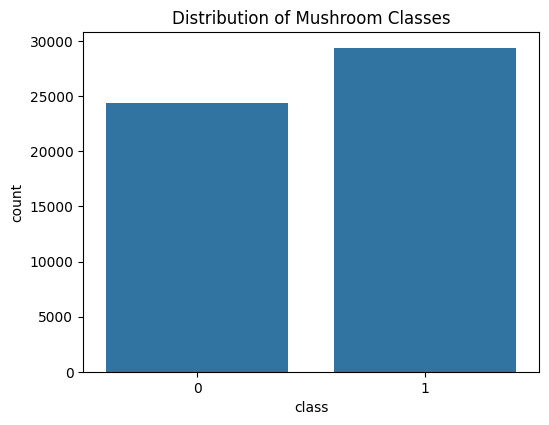

In [ ]:
predictions_pandas = predictions.select("class", "prediction").toPandas()

# Plot distributions and relationships
plt.figure(figsize=(20, 15))

# Distribution of Mushroom Classes
plt.subplot(3, 3, 1)
sns.countplot(data=mushroomDataset.toPandas(),
              x='class')
plt.title('Distribution of Mushroom Classes')

plt.show()


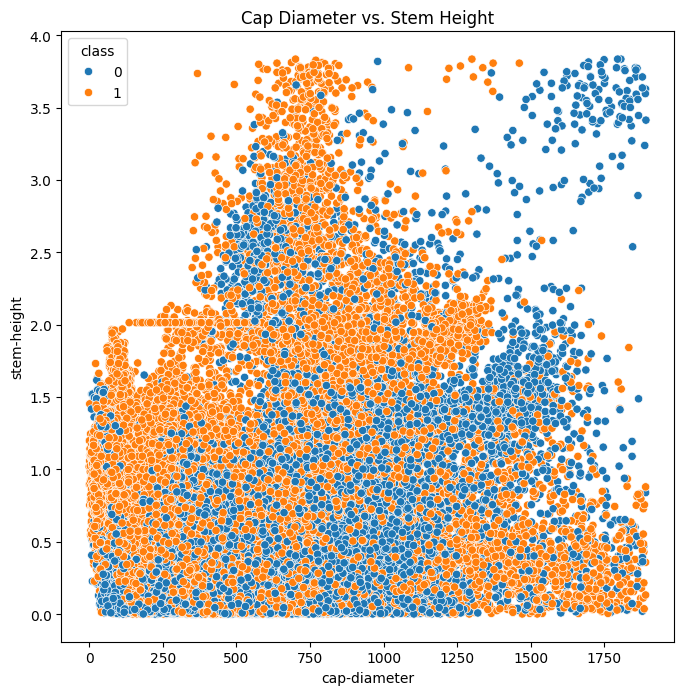

In [ ]:
# Cap Diameter vs. Stem Height

plt.figure(figsize=(20, 20))

plt.subplot(3, 3, 2)
sns.scatterplot(data=mushroomDataset.toPandas(),
                x='cap-diameter',
                y='stem-height',
                hue='class')

plt.title('Cap Diameter vs. Stem Height')

plt.tight_layout()
plt.show()

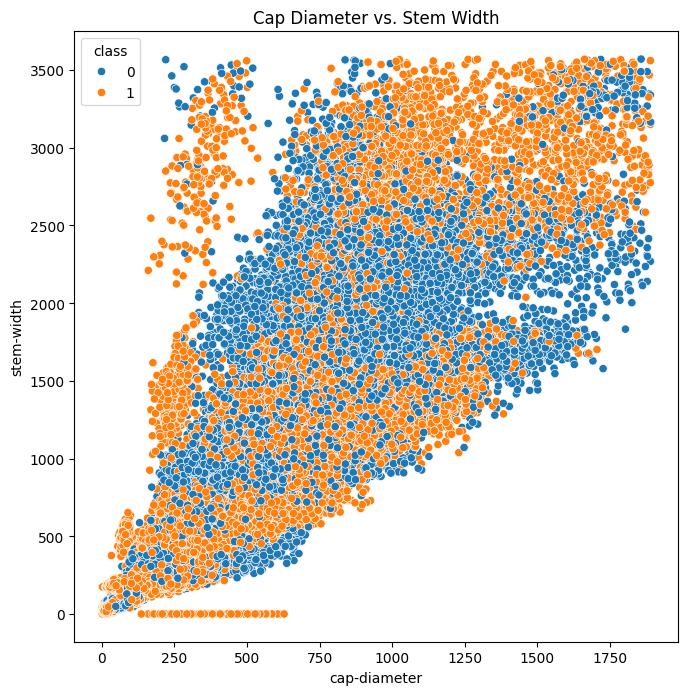

In [ ]:
# Cap Diameter vs. Stem Width

plt.figure(figsize=(20, 20))

plt.subplot(3, 3, 3)
sns.scatterplot(data=mushroomDataset.toPandas(),
                x='cap-diameter',
                y='stem-width',
                hue='class')

plt.title('Cap Diameter vs. Stem Width')

plt.tight_layout()
plt.show()

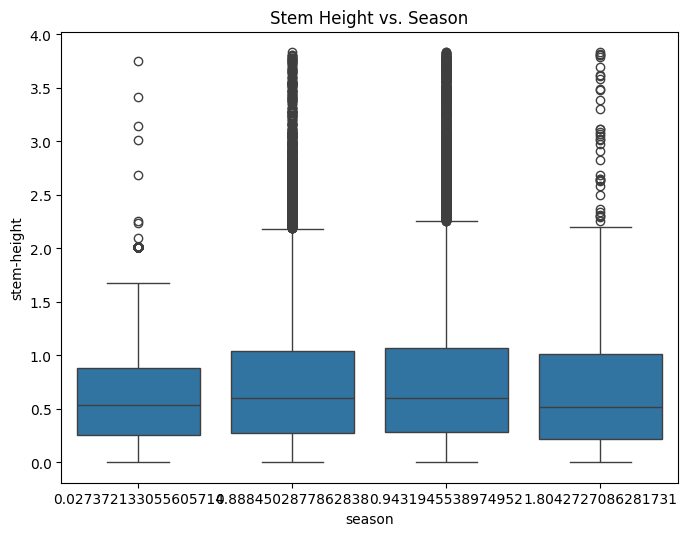

In [ ]:
# Stem Height vs. Season

plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 4)
sns.boxplot(data=mushroomDataset.toPandas(),
            x='season',
            y='stem-height')

plt.title('Stem Height vs. Season')

plt.tight_layout()
plt.show()

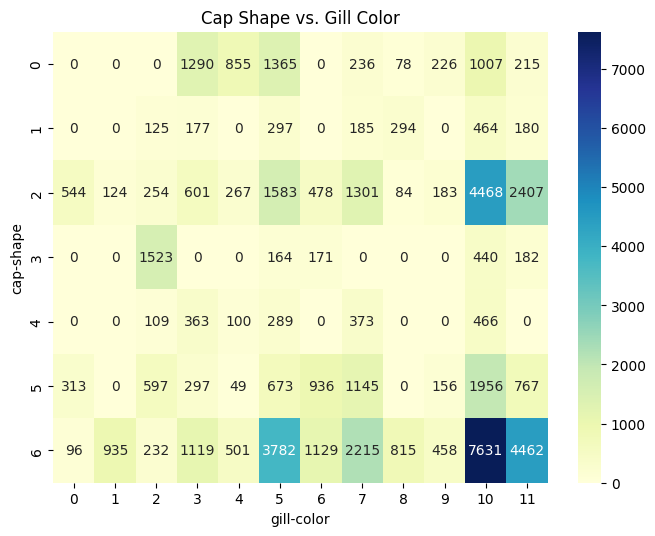

In [ ]:
#Cap Shape vs. Gill Color

plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 5)
cap_shape_gill_color = pd.crosstab(mushroomDataset.toPandas()['cap-shape'],
                                   mushroomDataset.toPandas()['gill-color'])

sns.heatmap(cap_shape_gill_color, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Cap Shape vs. Gill Color')

plt.tight_layout()
plt.show()

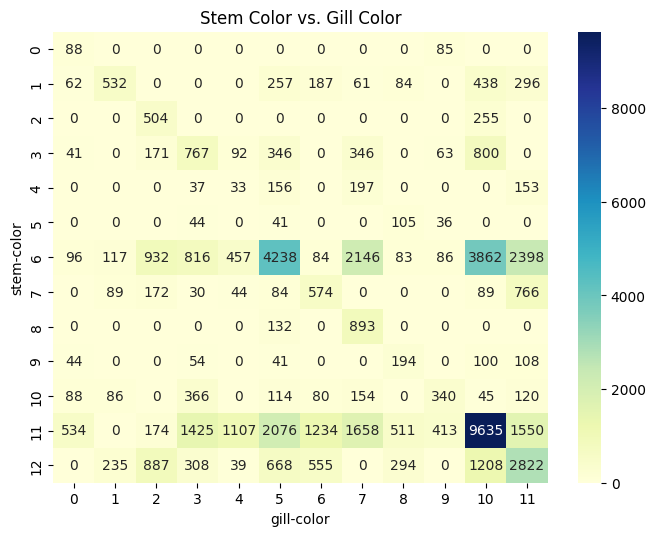

In [ ]:
#Stem Color vs. Gill Color

plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 6)
stem_color_gill_color = pd.crosstab(mushroomDataset.toPandas()['stem-color'],
                                    mushroomDataset.toPandas()['gill-color'])

sns.heatmap(stem_color_gill_color, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Stem Color vs. Gill Color')

plt.tight_layout()
plt.show()

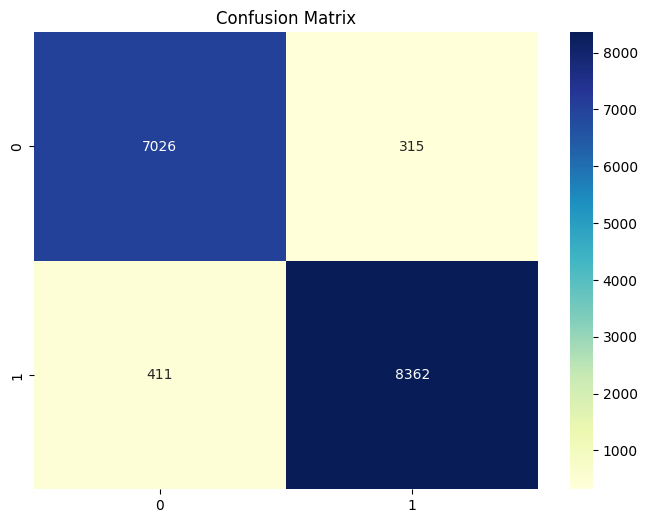

In [ ]:
# Confusion Matrix
plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 8)
conf_matrix = confusion_matrix(predictions_pandas['class'],
                               predictions_pandas['prediction'])

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
# Convert the Spark DataFrame to Pandas DataFrame
mushroom_df = mushroomDataset.toPandas()

# Filter the DataFrame to include only edible mushrooms
edible_mushrooms_df = mushroom_df[mushroom_df['class'] == 0]


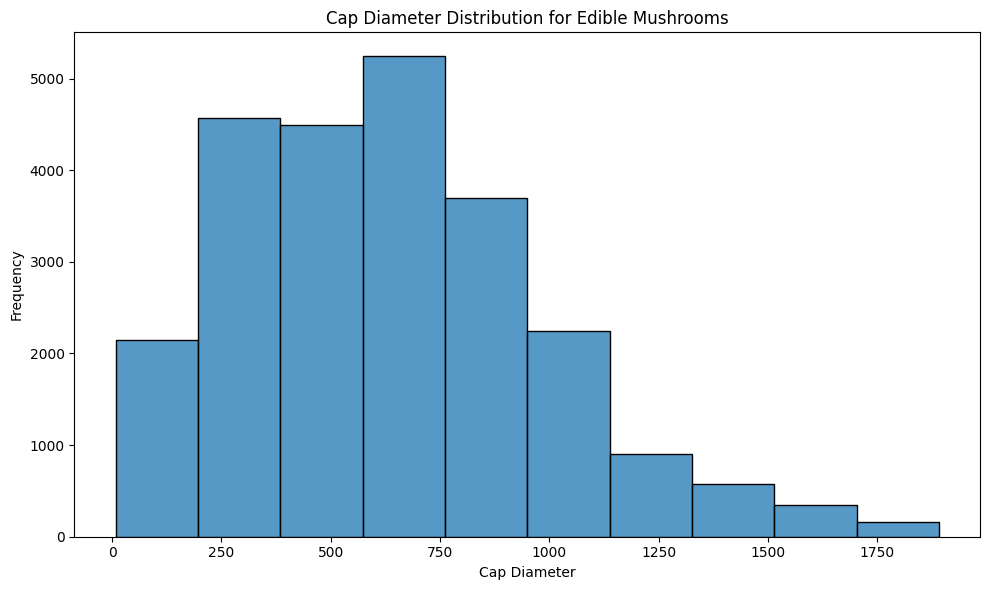

In [ ]:
# Cap Diameter Distribution for edible mushrooms
plt.figure(figsize=(10, 6))
sns.histplot(edible_mushrooms_df['cap-diameter'], bins=10, kde=False)
plt.title('Cap Diameter Distribution for Edible Mushrooms')
plt.xlabel('Cap Diameter')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

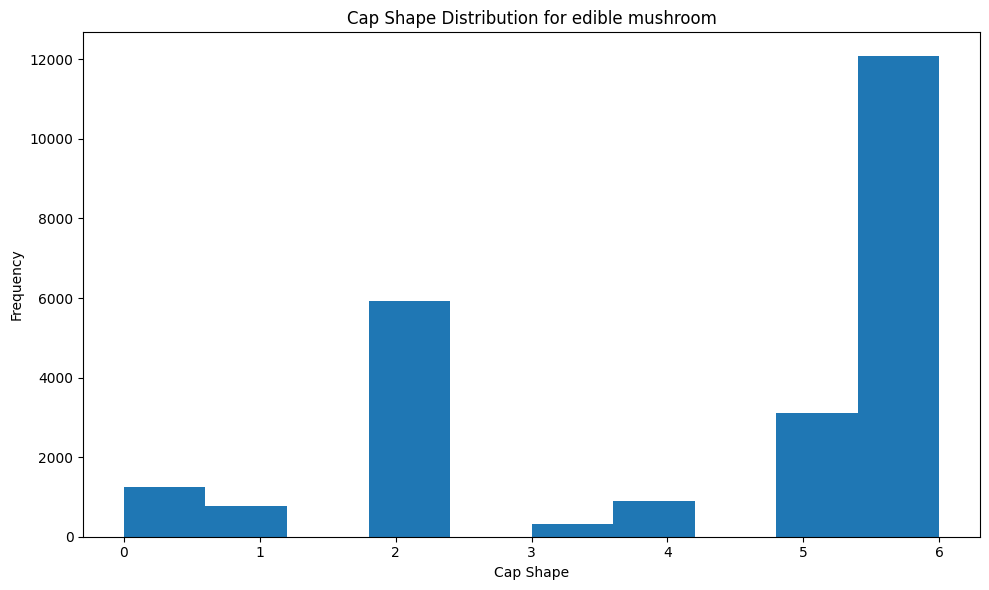

In [ ]:
#cap shape distribution for edible mushroom
plt.figure(figsize=(10, 6))
plt.hist(edible_mushrooms_df['cap-shape'], bins = 10)
plt.title('Cap Shape Distribution for edible mushroom')
plt.xlabel('Cap Shape')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

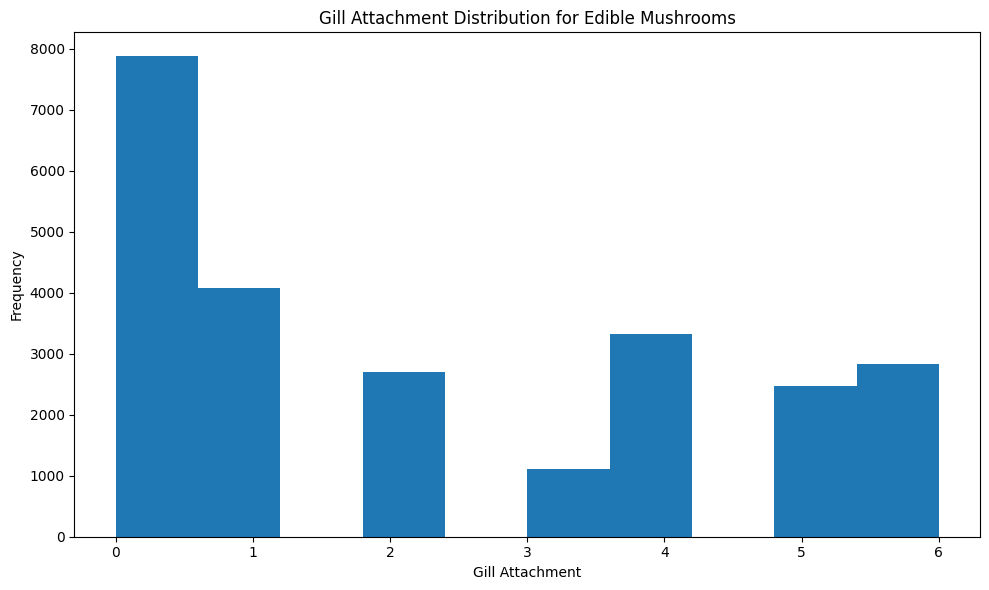

In [ ]:
# Gill Attachment Distribution for edible mushrooms
plt.figure(figsize=(10, 6))
plt.hist(edible_mushrooms_df['gill-attachment'], bins=10)
plt.title('Gill Attachment Distribution for Edible Mushrooms')
plt.xlabel('Gill Attachment')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

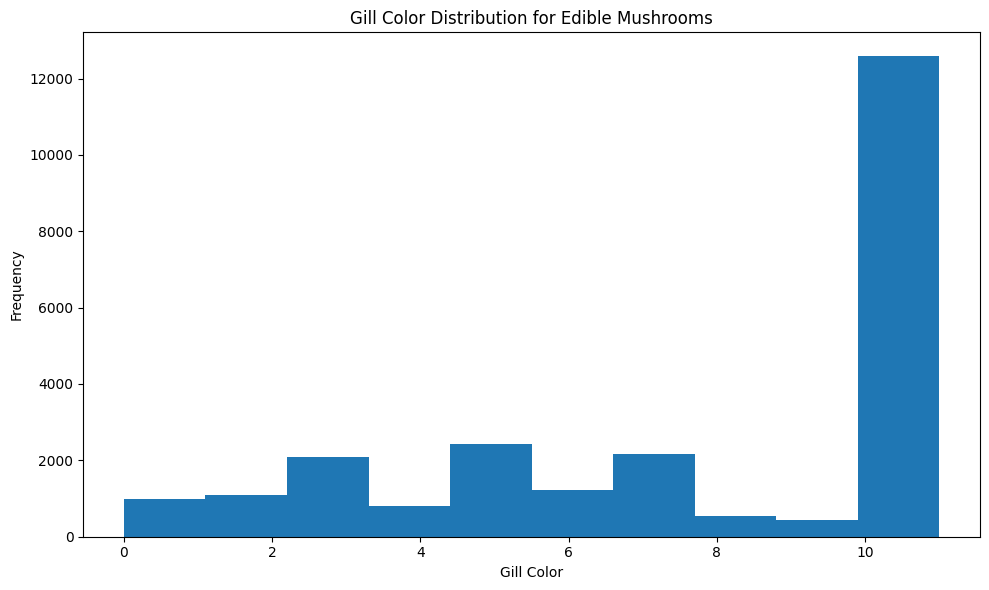

In [ ]:
# Gill Color Distribution for edible mushrooms
plt.figure(figsize=(10, 6))
plt.hist(edible_mushrooms_df['gill-color'], bins=10)
plt.title('Gill Color Distribution for Edible Mushrooms')
plt.xlabel('Gill Color')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


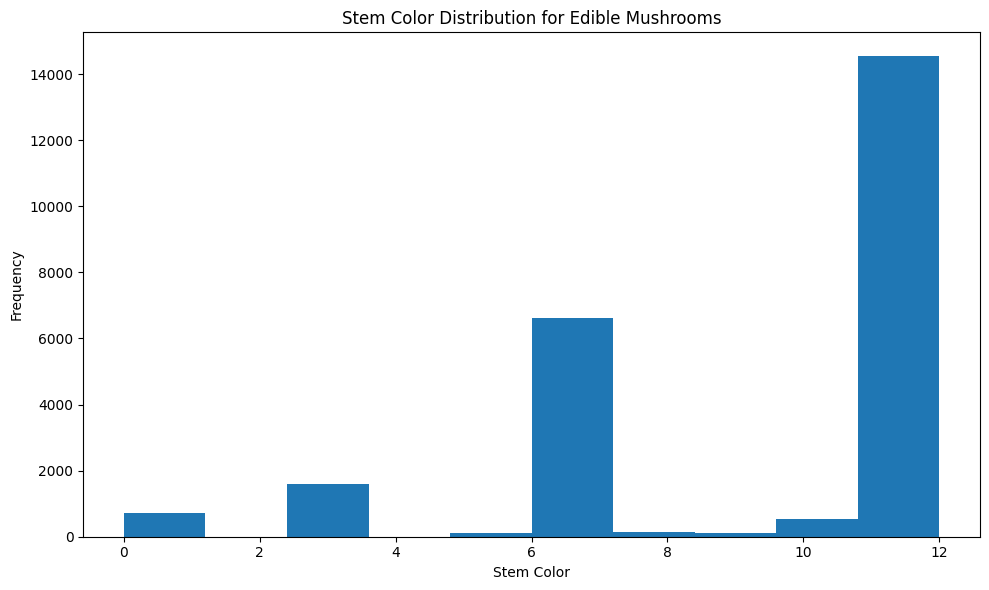

In [ ]:
# Stem Color Distribution for edible mushrooms
plt.figure(figsize=(10, 6))
plt.hist(edible_mushrooms_df['stem-color'], bins=10)
plt.title('Stem Color Distribution for Edible Mushrooms')
plt.xlabel('Stem Color')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

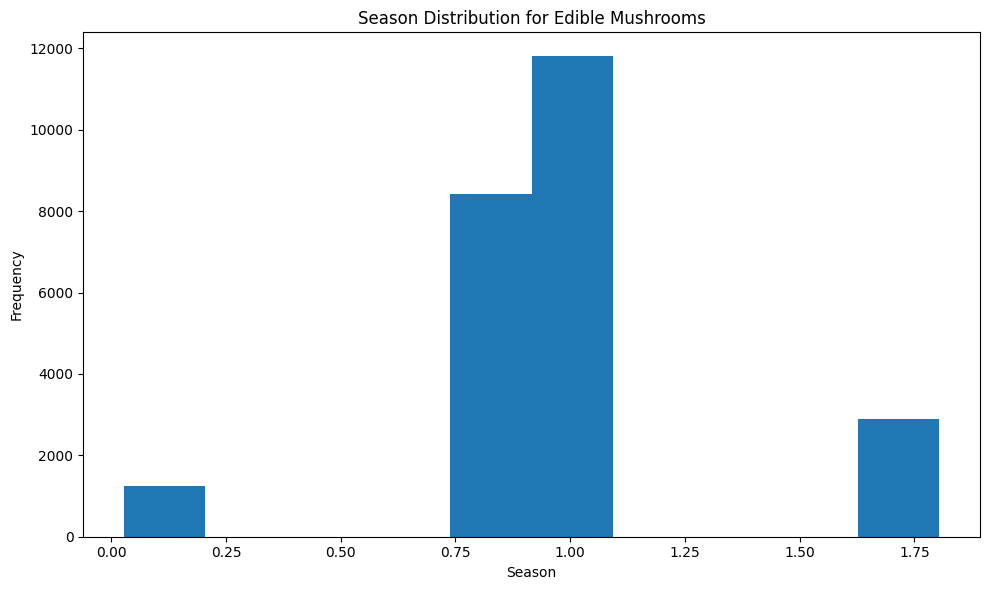

In [ ]:

# Season Distribution for edible mushrooms
plt.figure(figsize=(10, 6))
plt.hist(edible_mushrooms_df['season'], bins=10)
plt.title('Season Distribution for Edible Mushrooms')
plt.xlabel('Season')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()